# 37 sudoku solver

Write a program to solve a Sudoku puzzle by filling the empty cells.

A sudoku solution must satisfy all of the following rules:

Each of the digits 1-9 must occur exactly once in each row.
Each of the digits 1-9 must occur exactly once in each column.
Each of the digits 1-9 must occur exactly once in each of the 9 3x3 sub-boxes of the grid.
The '.' character indicates empty cells.

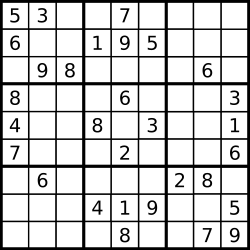

```
Input: board = 
[
["5","3",".",".","7",".",".",".","."],
["6",".",".","1","9","5",".",".","."],
[".","9","8",".",".",".",".","6","."],
["8",".",".",".","6",".",".",".","3"],
["4",".",".","8",".","3",".",".","1"],
["7",".",".",".","2",".",".",".","6"],
[".","6",".",".",".",".","2","8","."],
[".",".",".","4","1","9",".",".","5"],
[".",".",".",".","8",".",".","7","9"]
]

Output: [
["5","3","4","6","7","8","9","1","2"],
["6","7","2","1","9","5","3","4","8"],
["1","9","8","3","4","2","5","6","7"],
["8","5","9","7","6","1","4","2","3"],
["4","2","6","8","5","3","7","9","1"],
["7","1","3","9","2","4","8","5","6"],
["9","6","1","5","3","7","2","8","4"],
["2","8","7","4","1","9","6","3","5"],
["3","4","5","2","8","6","1","7","9"]
]
```
Explanation: The input board is shown above and the only valid solution is shown below:

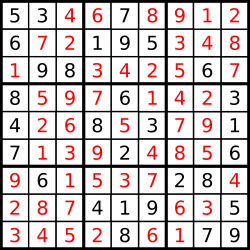

## Constraints:

board.length == 9
board[i].length == 9
board[i][j] is a digit or '.'.
It is guaranteed that the input board has only one solution.




# 🚀 0️⃣ Pattern Recognition (OBRIGATÓRIO)

## 🧠 Tipo do problema:

👉 **Constraint Satisfaction Problem (CSP) + Backtracking**

---

## 🎯 Ideia central:

Preencher células vazias (`.`) com números de `1-9` respeitando:

* linha
* coluna
* subgrid 3x3

---

## 🔥 Estratégia escolhida:

> Backtracking com sets para constraints O(1)

---

## Por que isso vence outras abordagens?

* brute force: 9^(81) ❌ impossível
* BFS/DFS grid: não modela constraints corretamente ❌
* greedy: falha em conflitos globais ❌

✔ backtracking + pruning = único viável

---

# 1️⃣ Specification

## 🎯 Core

Preencher o Sudoku in-place garantindo que cada linha, coluna e bloco 3x3 contenha números únicos de 1 a 9.

---

## 🧩 Blueprint

```python
from typing import List

class Solution:
    def solveSudoku(self, board: List[List[str]]) -> None:
        pass
```

---

## ⚠️ Edge Cases & Traps

1. Sudoku já parcialmente resolvido (poucas decisões)
2. Muitos blanks → explosão de backtracking
3. múltiplas soluções possíveis (mas normalmente 1)
4. blocos 3x3 são a principal fonte de bug
5. escolha ruim de célula causa TLE

---

# 2️⃣ Plan

## 🧠 Estratégia

Para cada célula vazia:

> tentar números de 1 a 9

Mas com pruning:

* não pode repetir na linha
* não pode repetir na coluna
* não pode repetir no bloco

---

## 🔥 Otimização chave (MVP de entrevista)

Usar sets:

```text id="state"
rows[i] → números usados na linha i
cols[j] → números usados na coluna j
boxes[k] → números usados no bloco 3x3
```

---

## 🧩 Visual Trace

Board parcial:

```text id="grid"
5 3 . | . 7 . | . . .
6 . . | 1 9 5 | . . .
. 9 8 | . . . | . 6 .
```

### Célula (0,2):

Testando:

```
try 1 → invalid (row conflict)
try 2 → valid
try 3 → valid
...
```

---

## 🔥 Backtracking flow

```text id="flow"
cell → try digit → check constraints → recurse → undo
```

---

# 4️⃣ Complexity

## ⏱ Time Complexity

Worst case:

[
O(9^{m})
]

onde `m = número de células vazias`

Mas pruning reduz drasticamente na prática.

---

## 🧠 Space Complexity

[
O(81 + m)
]

* board: O(81)
* recursion: O(m)
* sets: O(81)

---

# 5️⃣ Refinement

## 🧩 Otimização importante (nível interview forte)

👉 escolher sempre a célula com MENOS possibilidades primeiro (MRV heuristic)

Isso reduz drasticamente o branching.

---

## 🚀 Production considerations

* timeout safety (important)
* logging backtracking depth
* deterministic ordering (for reproducibility)
* input validation (board integrity)

---

# 🧠 Insight final (muito importante)

Sudoku é:

> N-Queens + Crossword em um único problema

* N-Queens → constraints globais
* Crossword → assignment
* Sudoku → ambos ao mesmo tempo

---

# 🔥 Fechamento mental

Se N-Queens te ensinou:

> “evitar conflito global”

E Crossword te ensinou:

> “atribuir elementos corretamente”

👉 Sudoku te ensina:

> “combinar múltiplas restrições simultâneas em decisão incremental”

---

Se quiser, próximo passo posso te mostrar:

🔥 como transformar Sudoku em Graph Coloring (isso conecta tudo em uma única teoria de CSP de entrevistas).


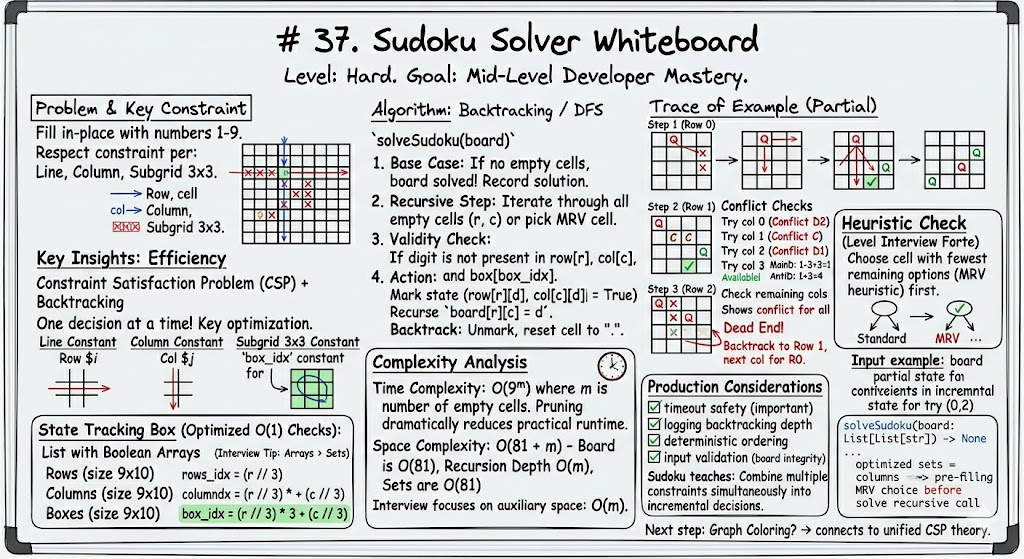

In [ ]:
from typing import List

class Solution:
    def solveSudoku(self, board: List[List[str]]) -> None:

        rows = [set() for _ in range(9)]
        cols = [set() for _ in range(9)]
        boxes = [set() for _ in range(9)]

        # ---------------------------
        # init state
        # ---------------------------
        for r in range(9):
            for c in range(9):
                if board[r][c] != '.':
                    val = board[r][c]
                    b = (r // 3) * 3 + (c // 3)
                    rows[r].add(val)
                    cols[c].add(val)
                    boxes[b].add(val)

        DIGITS = [str(i) for i in range(1, 10)]
        # ---------------------------
        # DFS backtracking
        # ---------------------------
        def backtrack(r, c):

            # move to next cell
            if c == 9:
                return backtrack(r + 1, 0)

            if r == 9:
                return True

            if board[r][c] != '.':
                return backtrack(r, c + 1)

            b = (r // 3) * 3 + (c // 3)

            for num in DIGITS:

                # pruning O(1)
                if num in rows[r] or num in cols[c] or num in boxes[b]:
                    continue

                # place
                board[r][c] = num
                rows[r].add(num)
                cols[c].add(num)
                boxes[b].add(num)

                # recurse
                solved = backtrack
                if solved:
                    return True

                # undo
                board[r][c] = '.'
                rows[r].remove(num)
                cols[c].remove(num)
                boxes[b].remove(num)

            return False

        backtrack(0, 0)